In [2]:
%cd ..
%pwd

/home/cveihmeyer_umass_edu/HeST


'/home/cveihmeyer_umass_edu/HeST'

In [3]:
import os
import sys
import HeST as hest
import HeST.Amherst_split_cpd_with_numba as examp
import numpy as np
import matplotlib.pyplot as plt
import HeST.Detection as detection
from numba import jit
# from tqdm import tqdm
from analysis.analysis_functions import *
import astropy.stats as astat
from scipy.interpolate import interp1d
import pickle

In [7]:
# need to load in the evaporation file (which is a pickle) and make the basic plots


with open('./data/new_batch_pracrice.pkl', 'rb') as f:
    slurm_practice = pickle.load(f)





[ True False False ... False False False]
[False  True  True ...  True  True False]
[False False False ... False False False]
[False False False ... False False  True]
[False False False ... False False  True]
[False False False ...  True  True False]
[False False False ... False False False]
[ True  True  True ... False False False]


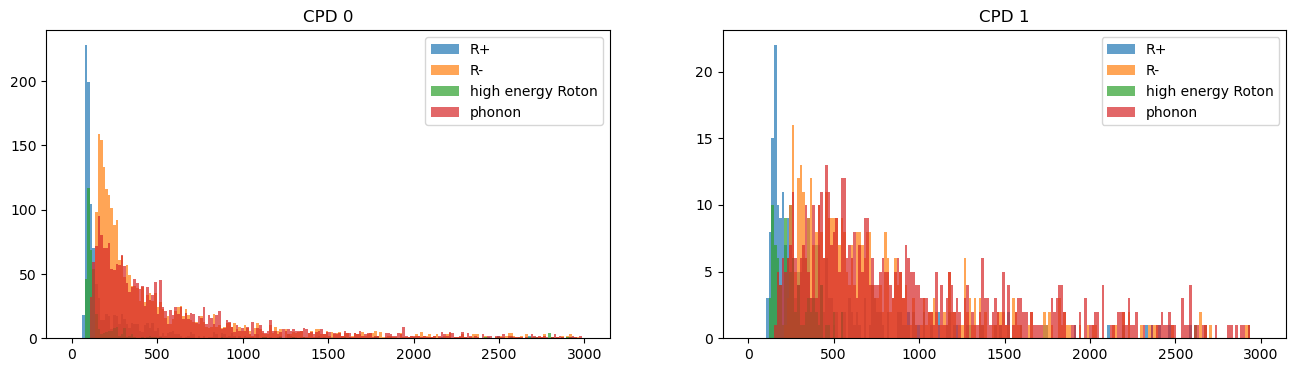

In [3]:
plot_hist_flavors(slurm_practice)

In [4]:
# write a file name 
import time 
import os
# this will be used in the saving that we do later, so I should add this line to HeST basic script
name_directory =os.path.join('', time.strftime('%y%m%d', time.gmtime()))

for i in range(1000):
    with open(os.path.join('parameters', 'sample_1000.txt'), 'a+') as f:
        f.write(f'sample_1000/point_{i}.pkl')
        f.write('\n')


In [5]:
# the goal of this is to sweep through the files, collect the channel sums, and then move save that and move on. 
import glob
file_list = glob.glob('./data/sample_1000/*')

channel_1 = np.empty(len(file_list))
channel_2 = np.empty(len(file_list))
for i, file in enumerate(file_list):
    with open(file, 'rb') as f:
        evap = pickle.load(f)
        channel_1[i] = len(evap.arrivalTimes_us[0])
        channel_2[i] = len(evap.arrivalTimes_us[1])
np.savetxt('./data/ch1_ch2_comparison/sample_run_data.txt', np.column_stack((channel_1, channel_2)))
config = {}
config['diff_prob'] = 0.8
config['refl_prob'] = 0.3
config['evap_eff'] = 0.6
config['num_qps'] = 10000
with open("config.txt", "w+") as file:
    for key, value in config.items():
        file.write(f"{key}={value}\n")

(0.0, 8000.0)

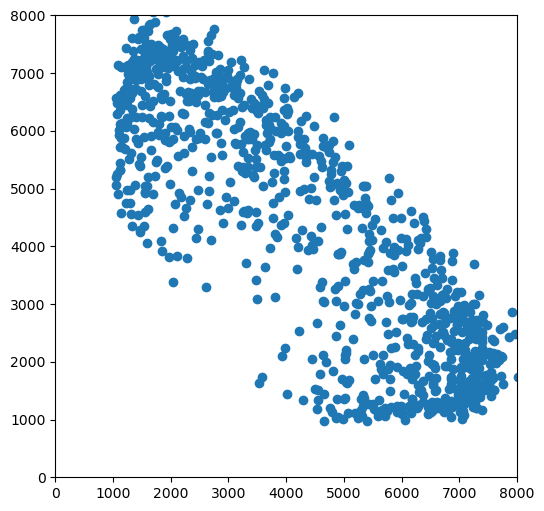

In [6]:
fig, ax = plt.subplots(figsize = (6,6))
ax.scatter(channel_1, channel_2)
ax.set_aspect('equal',adjustable= 'box')
ax.set_xlim(0, 8000)
ax.set_ylim(0, 8000)

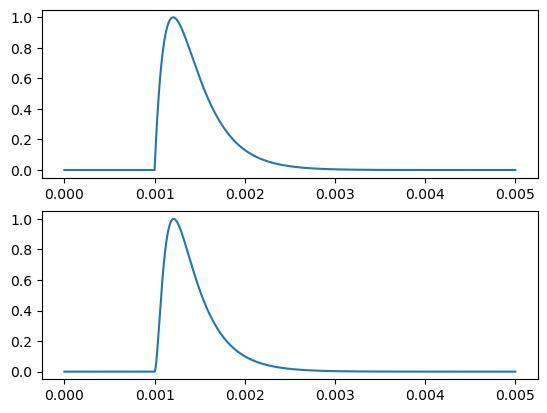

In [7]:
cpd1_template = np.load('./data/dispersion_curves/template_cpd1_evaporation.npy')
cpd2_template = np.load('./data/dispersion_curves/template_cpd2_evaporation.npy')
time = np.load('./data/dispersion_curves/template_time.npy')


fig, (ax0, ax1) = plt.subplots(2,1)
ax0.plot(time, cpd1_template)
ax1.plot(time, cpd2_template)

In [ ]:
# cpd1_hits = np.histogram(slurm_practice.arrivalTimes_us[0], bins=200)[0] *10e-3
# cpd2_hits = np.histogram(slurm_practice.arrivalTimes_us[1], bins=200)[0] * 10e-3


signal = np.convolve(cpd1_hits, cpd1_template)
plt.plot(signal)
signal = np.convolve(cpd2_hits, cpd2_template)
plt.plot(signal)

NameError: name 'slurm_practice' is not defined

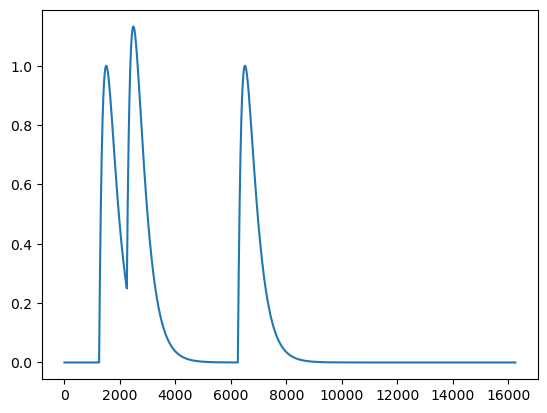

In [22]:
sample = np.zeros((10000,))
sample[0]=1
sample[1000]=1
sample[5000]=1
plt.plot(np.convolve(cpd1_template, sample))

[False False False ... False False  True]
[False  True False ...  True  True False]
[False False False ... False False False]
[ True False  True ... False False False]
[False False  True ... False  True False]
[ True  True False ...  True False False]
[False False False ... False False False]
[False False False ... False False  True]


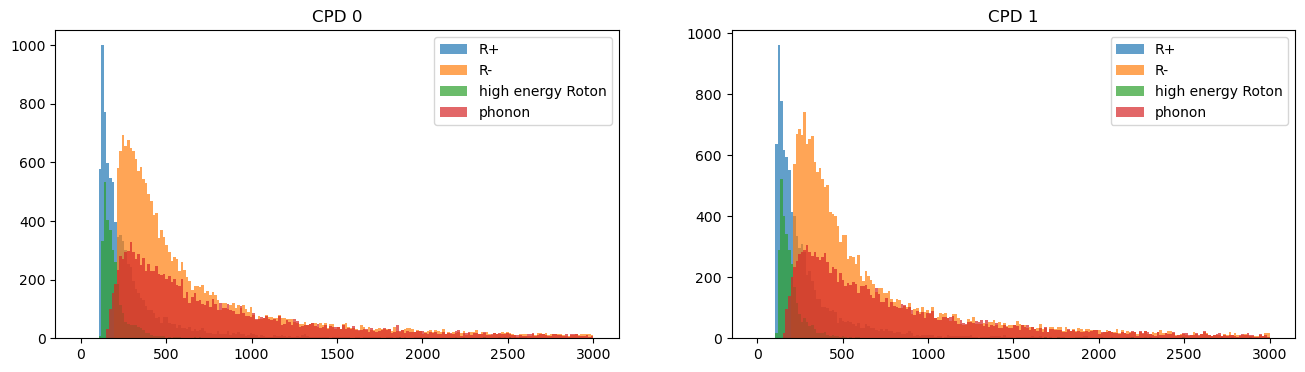

<Figure size 640x480 with 0 Axes>

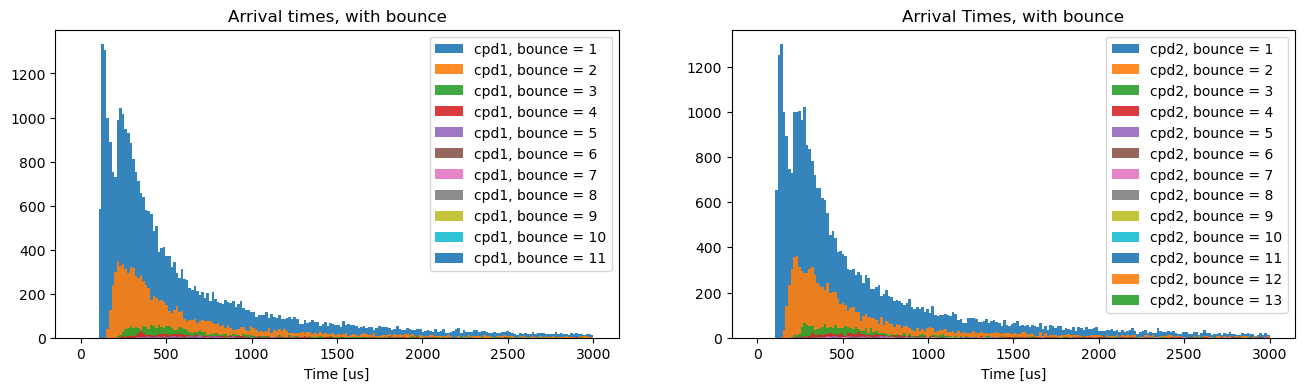

In [5]:
# need to load in the evaporation file (which is a pickle) and make the basic plots


with open('/work/pi_shertel_umass_edu/many_run_data/more_quasiparticles.pkl', 'rb') as f:
    many_qps = pickle.load(f)
plot_hist_flavors(many_qps)
plot_stacked_hist(many_qps)



Text(0.5, 1.0, 'CPD 1 pulse comparison')

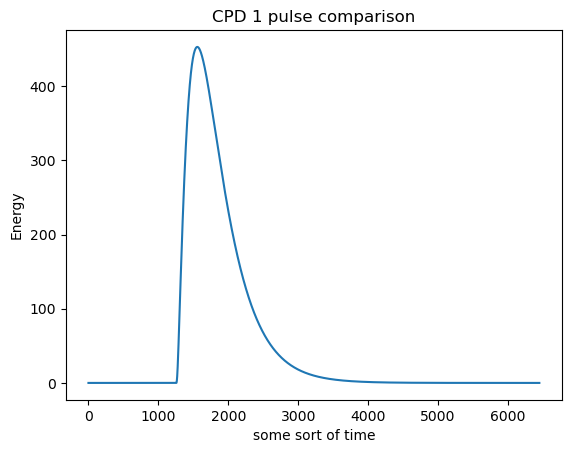

In [10]:
cpd1_hits = np.histogram(many_qps.arrivalTimes_us[0], bins=200, range = [0,3000])[0] *10e-3
cpd2_hits = np.histogram(many_qps.arrivalTimes_us[1], bins=200, range = [0,3000])[0] * 10e-3
plt.plot(np.convolve(cpd1_hits, cpd1_template))
plt.xlabel('some sort of time')
plt.ylabel('Energy')
plt.title('CPD 1 pulse comparison')

(array([   0.,    0.,    0.,    0.,    0.,    0.,    0.,  585., 1332.,
        1306., 1036., 1015.,  991., 1029., 1344., 1384., 1382., 1304.,
        1278., 1268., 1176., 1095., 1049., 1011.,  977.,  886.,  860.,
         806.,  743.,  748.,  640.,  645.,  642.,  594.,  564.,  503.,
         534.,  493.,  458.,  498.,  409.,  398.,  357.,  333.,  366.,
         328.,  337.,  334.,  293.,  305.,  276.,  309.,  278.,  254.,
         232.,  239.,  237.,  241.,  224.,  232.,  200.,  218.,  231.,
         217.,  183.,  177.,  194.,  183.,  141.,  148.,  150.,  144.,
         160.,  143.,  140.,  145.,  134.,  162.,  126.,  128.,  131.,
         131.,  116.,  127.,  118.,   90.,  102.,  114.,  100.,  104.,
         108.,   99.,   94.,   92.,   86.,  100.,   73.,   92.,   93.,
          74.,   79.,   66.,  100.,   85.,   79.,   70.,   80.,   66.,
          56.,   72.,   79.,   62.,   64.,   65.,   61.,   58.,   64.,
          63.,   70.,   65.,   67.,   46.,   62.,   71.,   56.,   56.,
      

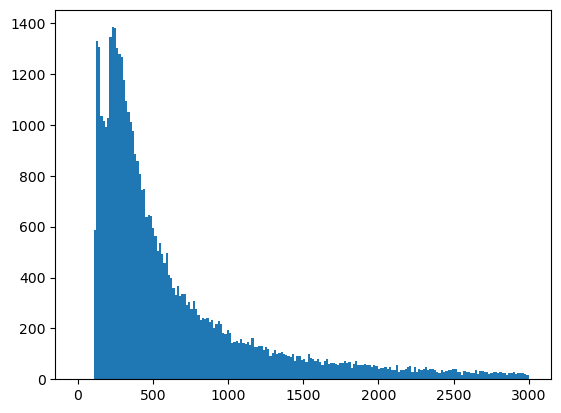

In [11]:
plt.hist(many_qps.arrivalTimes_us[0], bins=200, range = [0,3000])